# Headers

In [1]:
import numpy as np
import pandas as pd

import pickle

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os
import io
from contextlib import redirect_stdout, redirect_stderr

import pickle

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.fit_scripts import fit_distr_double_gauss
from analysis_scripts.fit_scripts import fit_distr_double_gauss_alternative_input
from analysis_scripts.fit_scripts import fit_distr_double_gauss_and_pol2
from analysis_scripts.fit_scripts import fit_distr_double_gauss_and_pol2_end_exp
from analysis_scripts.selection_scripts import auto_preselection
from analysis_scripts.estimate_scripts import get_mass_distributions
from analysis_scripts.draw_scripts import total_spectrum
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_const
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_pol2



CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Prepare Data

**Same as in data_explore.ipynb**

In [2]:
data_oc_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_2_new.csv')
data_mb_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_2_new.csv')

In [3]:
raw_df_list = []

for data_oc_df, data_mb_df in zip([data_oc_df_2, data_oc_df_1], [data_mb_df_2, data_mb_df_1]):
    
    data_oc_df = data_oc_df.drop(['n_event'], axis=1)

    mass_mask = (data_oc_df['mass_Lc'] > CFG.mass_interval[0]) \
                & ( data_oc_df['mass_Lc'] < CFG.mass_interval[1]) \
                & (data_oc_df['true_decay'] == 1)
    
    data_oc_df = data_oc_df[mass_mask]
    data_oc_df['tag'] = 'Sig'

    data_mb_df = data_mb_df.drop(['n_event'], axis=1)

    mass_mask = (data_mb_df['mass_Lc'] > CFG.mass_interval[0]) & ( data_mb_df['mass_Lc'] < CFG.mass_interval[1])

    data_mb_df = data_mb_df[mass_mask]
    data_mb_df['tag'] = 'Bg'

    raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)
    
    raw_df = raw_df.copy()
    
    raw_df_list.append(raw_df)

In [4]:
proc_df_list = []

selection_mask_train = None

for raw_df in raw_df_list:
    
    proc_df = raw_df.copy()

    # min_tracks_after_re_fit = 7
    # proc_df = proc_df[proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit]

    features_to_select = [
        # Default features
        # 'P_p', 'P_pip', 'P_K',
        # 'eta_p', 'eta_pip', 'eta_K', 
        # 'P_Lc', 'Pt_Lc', 'eta_Lc',
        # 'Pt_p', 'Pt_K', 'Pt_pip',
        'lengthXY_Lc', 'dlengthXY_Lc', 'ctau_Lc', 
        'chi2_Lc_PV_xy', 'dist_Lc_PV_xy', 'dist_Lc_PV_xy_custom',
        'chi2_p_PV_xy', 'dist_p_PV_xy', 'dist_p_PV_xy_custom',
        'chi2_K_PV_xy', 'dist_K_PV_xy', 'dist_K_PV_xy_custom', 
        'chi2_pip_PV_xy','dist_pip_PV_xy', 'dist_pip_PV_xy_custom', 
        'chi2_p_Lc_xy','dist_p_Lc_xy', 'dist_p_Lc_xy_custom',
        'chi2_K_Lc_xy', 'dist_K_Lc_xy', 'dist_K_Lc_xy_custom',
        'chi2_pip_Lc_xy', 'dist_pip_Lc_xy', 'dist_pip_Lc_xy_custom',
        'chi2_K_pip_xy', 'dist_K_pip_xy','dist_K_pip_xy_custom',
        'chi2_p_K_xy', 'dist_p_K_xy', 'dist_p_K_xy_custom',
        'chi2_p_pip_xy', 'dist_p_pip_xy', 'dist_p_pip_xy_custom',
        'cosAngle_momentum_Lc_sum_momentum_xy', 'chi2_Lc', 'xF',
        # 'cosAngle_r_Lc_momentum_Lc_xy_left',
        # 'cosAngle_r_Lc_momentum_Lc_xy_right',
        # 'cosAngle_r_Lc_sum_momentum_xy_left',
        # 'cosAngle_r_Lc_sum_momentum_xy_right',
    ]

    quantile_dict = {}

    selection_df, mask = auto_preselection(
        df=proc_df,
        features=features_to_select,
        safety_interval=0.95,
        indent=2,
        quantile_left=1e-3,
        quantile_right=1 - 1e-3,
        recursive=True,
        quantile_dict=quantile_dict,
    )

    if selection_mask_train is None:
        proc_df = proc_df.query(mask).reset_index(drop=True)
        selection_mask_train = mask
    else:
        proc_df = proc_df.query(selection_mask_train).reset_index(drop=True)

    proc_df_copy = proc_df.copy()

    sig_eff_presel = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc'].count()
    bg_eff_presel = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].count()

    print(f'Signal efficiency: {sig_eff_presel}')
    print(f'Background Suppression: {bg_eff_presel}')
    
    proc_df_list.append(proc_df)

Signal efficiency: 0.9471311915238197
Background Suppression: 0.6236141088465027
Signal efficiency: 0.9471810669404919
Background Suppression: 0.6200400630780377


In [5]:
proc_df = proc_df_list[1]

del proc_df_list[0]
del data_oc_df_1
del data_mb_df_1
del data_oc_df_2
del data_mb_df_2
del data_oc_df
del data_mb_df
del raw_df_list
del raw_df
del proc_df_copy

# PV FIT

In [6]:
# Remove duplicated PVs (single PV can contain several rows)

proc_PV_df = proc_df.drop_duplicates(subset=('id')).copy()
proc_PV_df = proc_PV_df[[
    'tag', 'PV_diff_ES_x', 'PV_diff_ES_y', 'PV_diff_ES_z'
]]
proc_PV_df = proc_PV_df.reset_index(drop=True)

proc_PV_df.head()

,tag,PV_diff_ES_x,PV_diff_ES_y,PV_diff_ES_z
0,Sig,0.001009,-0.004212,-0.005143
1,Sig,-0.004101,0.007971,0.011696
2,Sig,0.002510,0.003912,-0.000190
3,Sig,-0.001860,0.002775,-0.001198
4,Sig,0.006621,0.000625,0.009463


### PV x-projection

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 27
Final objective value: 92.317130
Chi-squared: 92.32
Reduced chi-squared: 2.797
---------------------------------------------

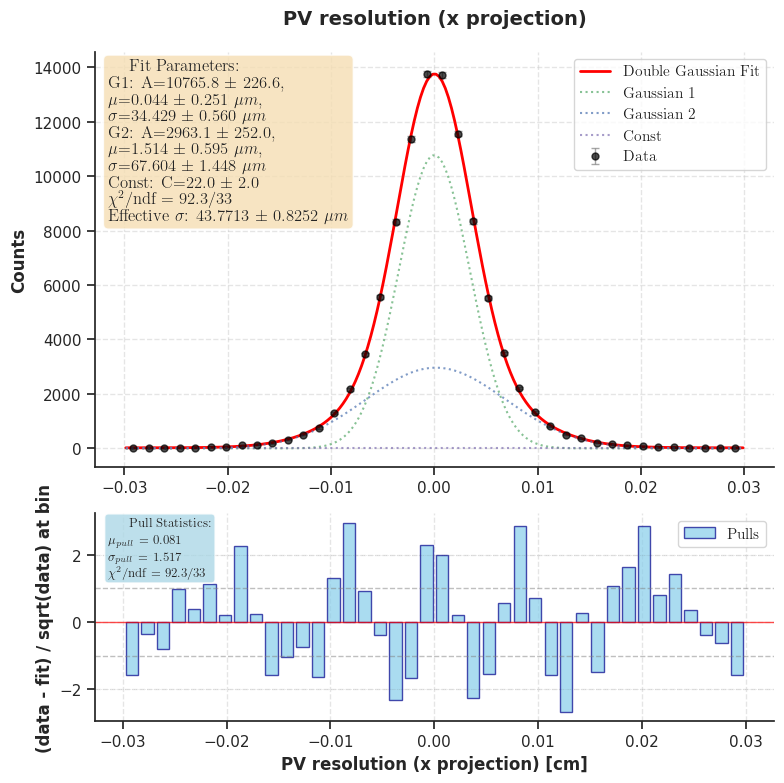

In [7]:
distr_name = 'PV_diff_ES_x'
distr = proc_PV_df.loc[proc_PV_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='PV resolution (x projection)',
    x_label='PV resolution (x projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf')

### PV y-projection

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_m

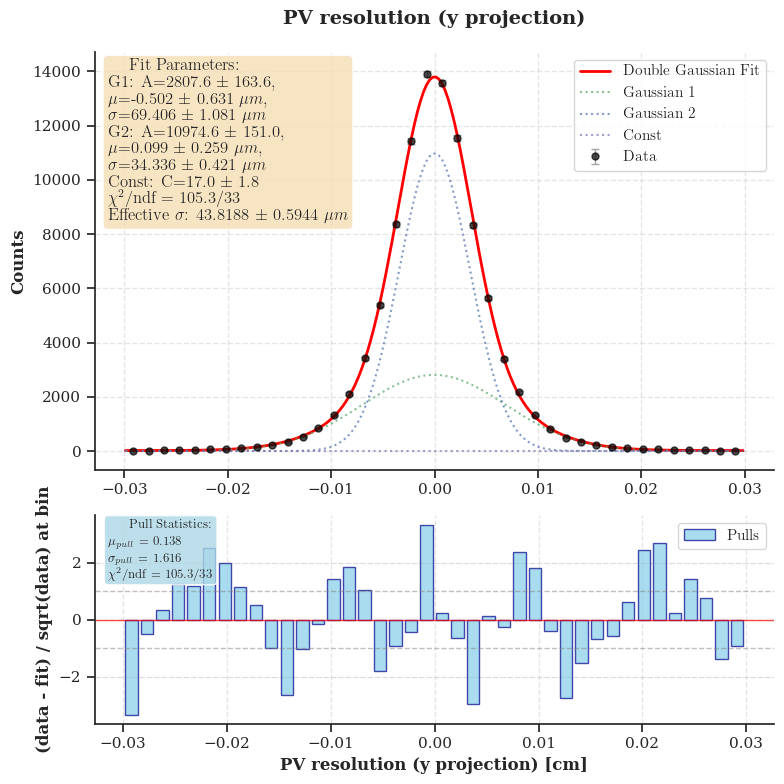

In [8]:
distr_name = 'PV_diff_ES_y'
distr = proc_PV_df.loc[proc_PV_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='PV resolution (y projection)',
    x_label='PV resolution (y projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf')

### PV z-projection

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_m

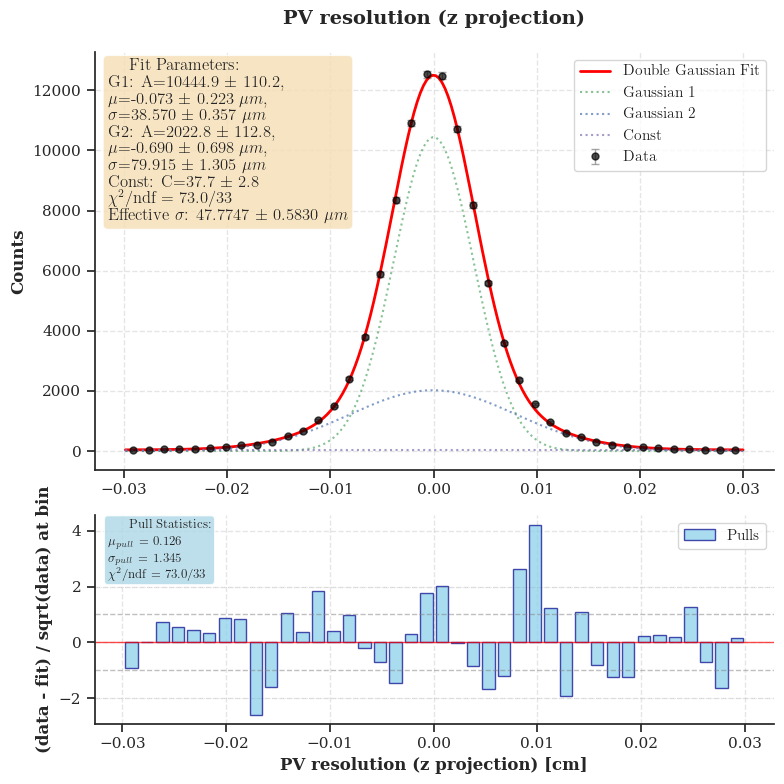

In [9]:
distr_name = 'PV_diff_ES_z'
distr = proc_PV_df.loc[proc_PV_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='PV resolution (z projection)',
    x_label='PV resolution (z projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf')

# SV FIT

### SV x-projection

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_m

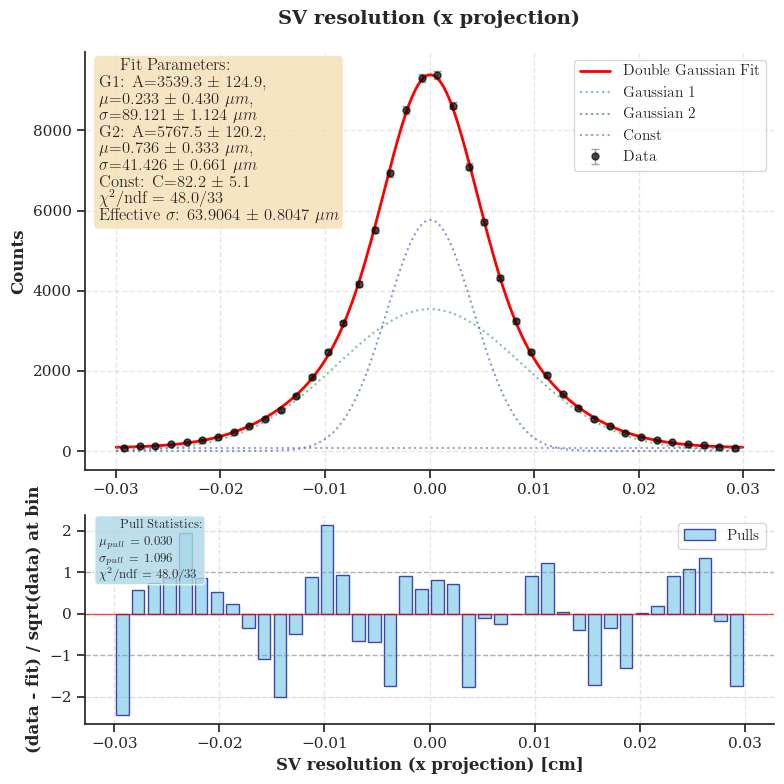

In [10]:
distr_name = 'Lc_diff_x'

distr = proc_df.loc[proc_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='SV resolution (x projection)',
    x_label='SV resolution (x projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf', bbox_inches='tight')

### SV y-projection

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 13
Final objective value: 61.542680
Chi-squared: 61.54
Reduced chi-squared: 1.865
---------------------------------------------

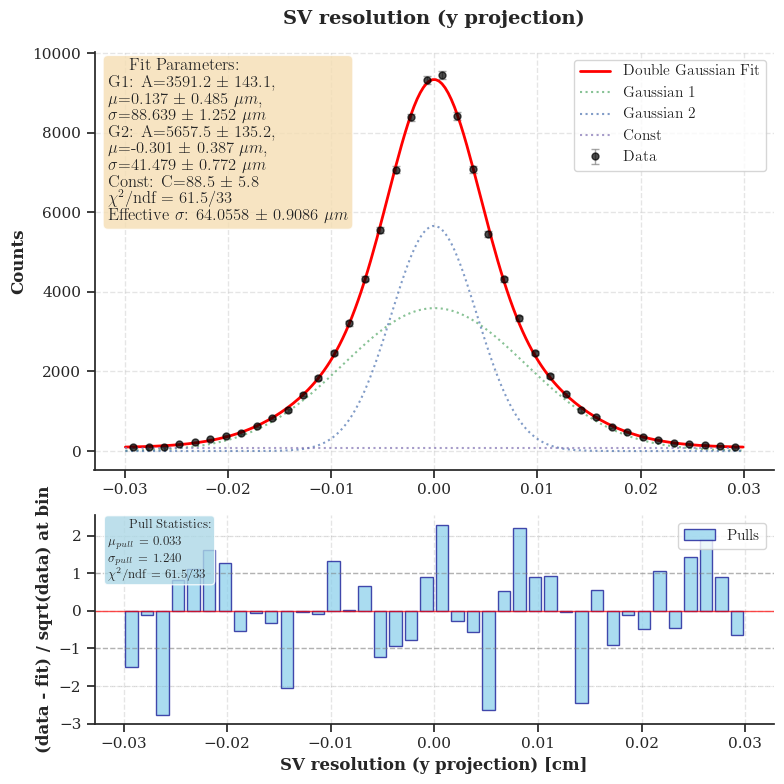

In [11]:
distr_name = 'Lc_diff_y'

distr = proc_df.loc[proc_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='SV resolution (y projection)',
    x_label='SV resolution (y projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf', bbox_inches='tight')

### SV z-projection

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_m

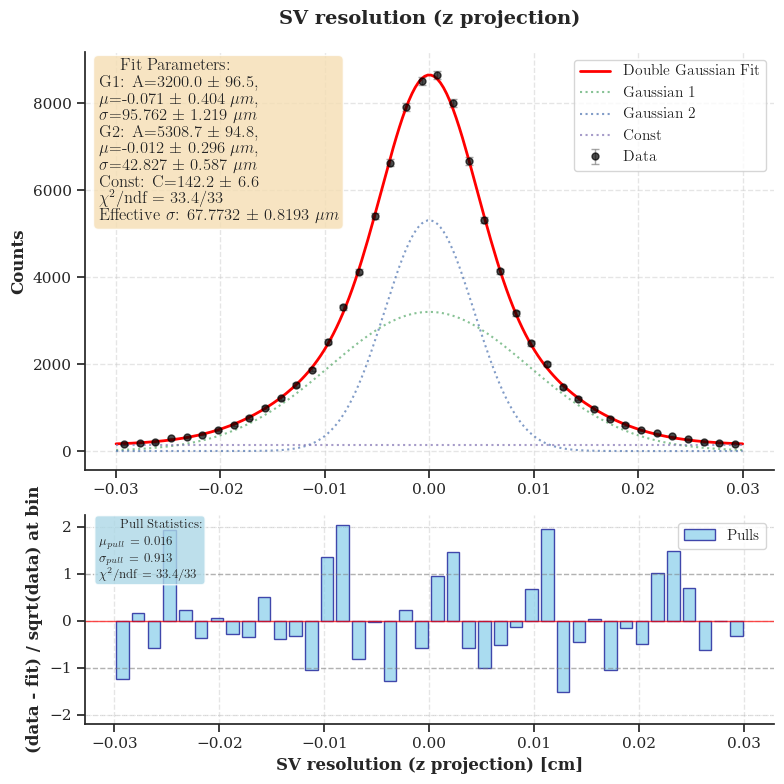

In [12]:
distr_name = 'Lc_diff_z'

distr = proc_df.loc[proc_df['tag'] == 'Sig', distr_name]
distr_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='SV resolution (z projection)',
    x_label='SV resolution (z projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf', bbox_inches='tight')

# Lc fit

<Axes: >

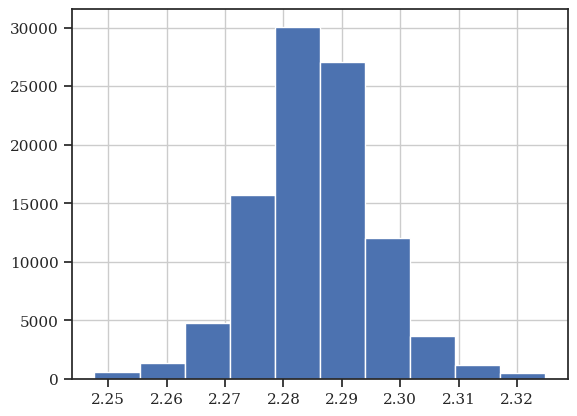

In [13]:
mass_Lc = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc']
mass_Lc.hist()

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_m

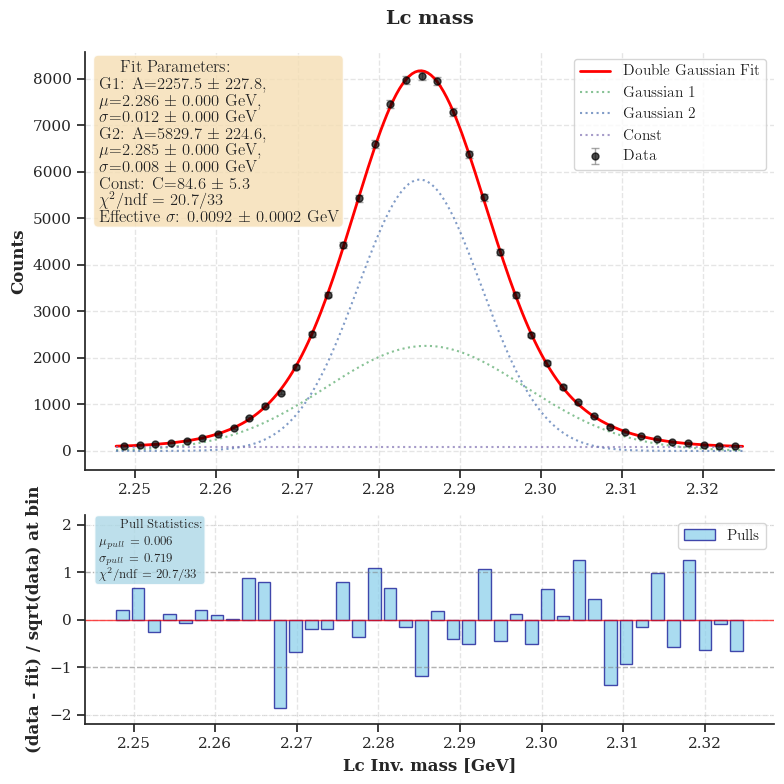

In [14]:
distr_name = 'Lc_mass'

distr = mass_Lc
distr_sel = distr

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1,
                unit_name='GeV'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=distr_sel,
    title='Lc mass',
    x_label='Lc Inv. mass [GeV]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1,
    unit_name='GeV'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf')

# Background fit

<Axes: >

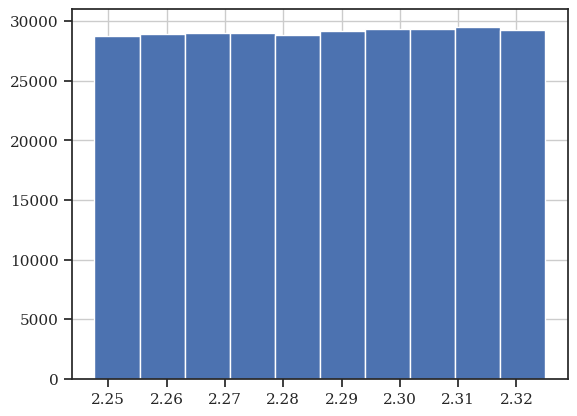

In [15]:
mass_bg = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc']
mass_bg.hist()

Method: Nelder-Mead
result['success']=True
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
result['success']=True
Method: CG
result['success']=True
Method: BFGS
result['success']=True
****************************************************************************************************
New best method: BFGS, success: True
****************************************************************************************************
Method: Newton-CG
Method: L-BFGS-B
result['success']=True
Method: TNC
result['success']=True
Method: COBYLA
Method: COBYQA
result['success']=np.True_
****************************************************************************************************
New best method: COBYQA, success: True
**************************************************************************

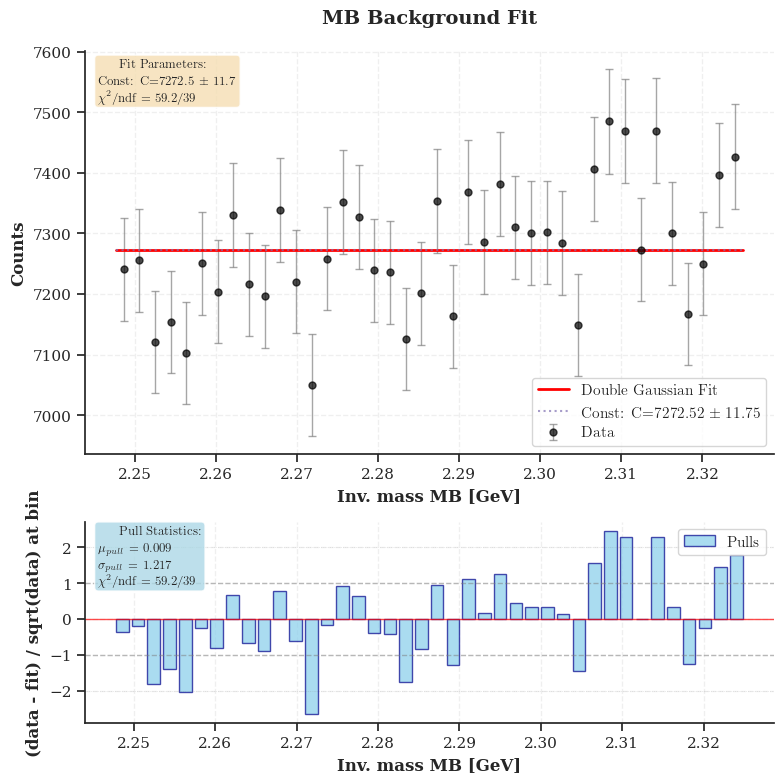

In [17]:
from analysis_scripts.fit_scripts import fit_distr_flat_bg


distr_name = 'Background'

distr = mass_bg
distr_sel = distr

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    # if method in ('SLSQP'):
    #     print(f'Skip method: {method}')
    #     continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_flat_bg(
                distr=distr_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    print(f'{result['success']=}')
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_flat_bg(
    distr=distr_sel,
    title='MB Background Fit',
    x_label='Inv. mass MB [GeV]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{distr_name}.pdf')

# Lc Combined Distributions Fit

## Load Data

In [2]:
test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_test_1.csv').drop('Unnamed: 0', axis=1)

assert not test_df.isna().sum().sum(), 'Test, data containes NaNs!!'

## Combined Fit

In [3]:
sig_mass_distr = test_df.loc[test_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = test_df.loc[test_df['tag'] == 'Bg', 'mass_Lc']

sig_eff = 0.0297
bg_eff = 6.186e-5

total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=CFG.mass_interval,
    gev_per_bin=0.000773
)

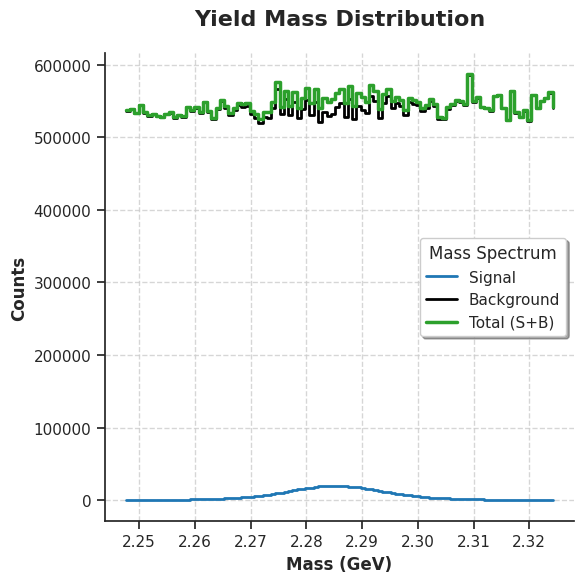

In [4]:
total_spectrum(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=CFG.mass_interval,
    gev_per_bin=0.000773,
    log_y=False,
    only_total=False,
    line_style='-'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/mass_stats_after_selection_cut_based_1.pdf', bbox_inches='tight')

Method: Nelder-Mead
****************************************************************************************************
New best method: Nelder-Mead, success: True
****************************************************************************************************
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
****************************************************************************************************
New best method: trust-constr, success: True
****************************************************************************************************
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
**

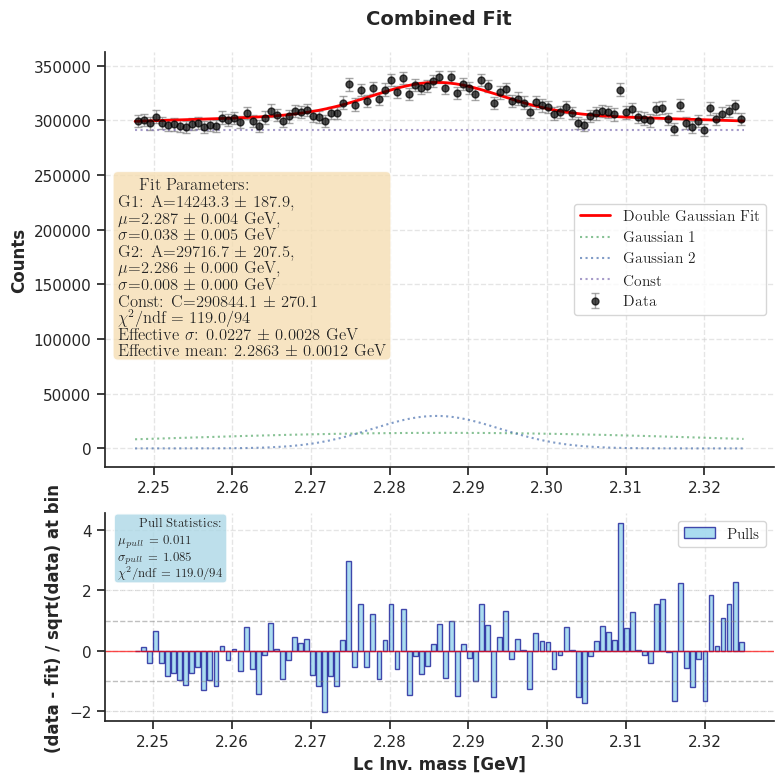

In [5]:
distr_name='total_mass'

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss_alternative_input(
                counts=total_heights,
                errors=total_heights_errors,
                bin_centers=bin_centers,
                bin_edges=bin_edges,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                max_iter=1000,
                scaler=1,
                unit_name='GeV'
            )
        except:
            print(f'Skip method: {method}') 
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss_alternative_input(
    counts=total_heights,
    errors=total_heights_errors,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    title='Combined Fit',
    x_label='Lc Inv. mass [GeV]',
    optimize_method=best_method,
    plot=True,
    max_iter=1000,
    scaler=1,
    unit_name='GeV',
    log_y=False,
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/combined_fit_ML.pdf')

### Get S/B ratio

In [ ]:
"""import pickle


with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/ML_fit_tuple_pickle.pkl", "wb") as f:
    pickle.dump(result, f)"""

In [ ]:
stat_data = calculate_sb_ratio_2gauss_const(result[0]['params'], bin_edges, cov_matrix=result[0]['cov_matrix'], mass_interval=None)
stat_data

{'signal': np.float64(1539.7531505241511),
 'background': np.float64(22493.71283176293),
 'S_B_ratio': np.float64(0.0684526010463642),
 'integration_range': (np.float64(2.2476303577423096),
  np.float64(2.32496976852417)),
 'S_B_uncertainty': np.float64(0.0018772023153338763)}

# Combined Fit Wide

## Load Data

In [2]:
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df = data_oc_df.drop(['n_event'], axis=1)

mass_mask = (data_oc_df['true_decay'] == 1)
                
data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

data_mb_df = data_mb_df.drop(['n_event'], axis=1)

data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)

raw_df['cosAngle_r_Lc_momentum_Lc_xy'] = raw_df['cosAngle_r_Lc_momentum_Lc_xy'].apply(np.cos)
raw_df['cosAngle_r_Lc_sum_momentum_xy'] = raw_df['cosAngle_r_Lc_sum_momentum_xy'].apply(np.cos)
raw_df['cosAngle_momentum_Lc_sum_momentum_xy'] = raw_df['cosAngle_momentum_Lc_sum_momentum_xy'].apply(np.cos)

In [3]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/preselection_mask_train_pickle.pkl", "rb") as f:
    preselection_mask = pickle.load(f)

proc_df = raw_df.query(preselection_mask).reset_index(drop=True)

proc_mass_min = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].min()
proc_mass_max = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].max()

In [4]:
sig_mass_distr = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc']

# ML sel
sig_eff = 0.0538
bg_eff = 3.44e-5

total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Yield Mass Distribution'}, xlabel='Mass (GeV)', ylabel='Counts'>)

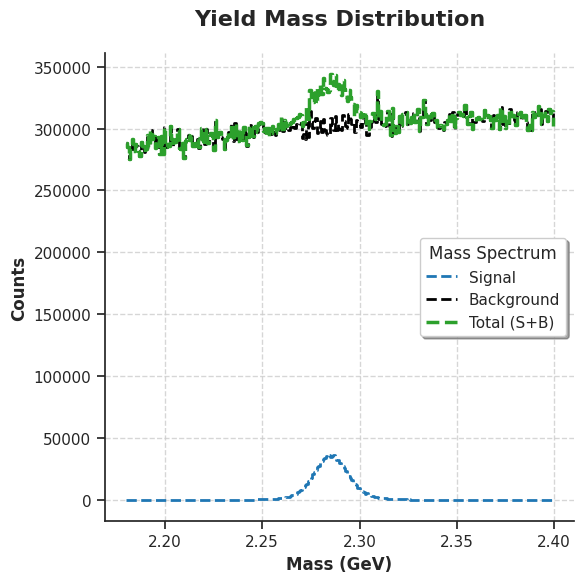

In [ ]:
total_spectrum(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773,
    log_y=False,
    only_total=False,
    line_style='-'
)

## Fit

### Double Gauss + Const

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
****************************************************************************************************
New best method: L-BFGS-B, success: True
****************************************************************************************************
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
****************************************************************************************************
New best method: trust-constr, success: True
****************************************************************************************************
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
*****

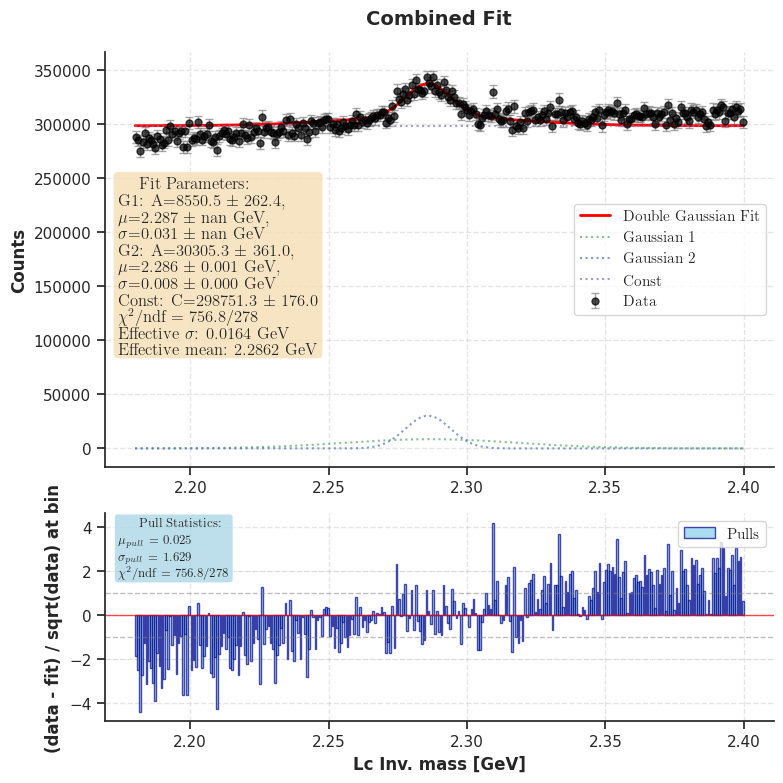

In [6]:
distr_name='total_mass'

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss_alternative_input(
                counts=total_heights,
                errors=total_heights_errors,
                bin_centers=bin_centers,
                bin_edges=bin_edges,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                max_iter=1000,
                scaler=1,
                unit_name='GeV'
            )
        except:
            print(f'Skip method: {method}') 
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss_alternative_input(
    counts=total_heights,
    errors=total_heights_errors,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    title='Combined Fit',
    x_label='Lc Inv. mass [GeV]',
    optimize_method=best_method,
    plot=True,
    max_iter=1000,
    scaler=1,
    unit_name='GeV',
    log_y=False,
)

# plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/combined_fit_ML.pdf')

### Double Gauss + Pol2

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
****************************************************************************************************
New best method: trust-constr, success: True
****************************************************************************************************
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_

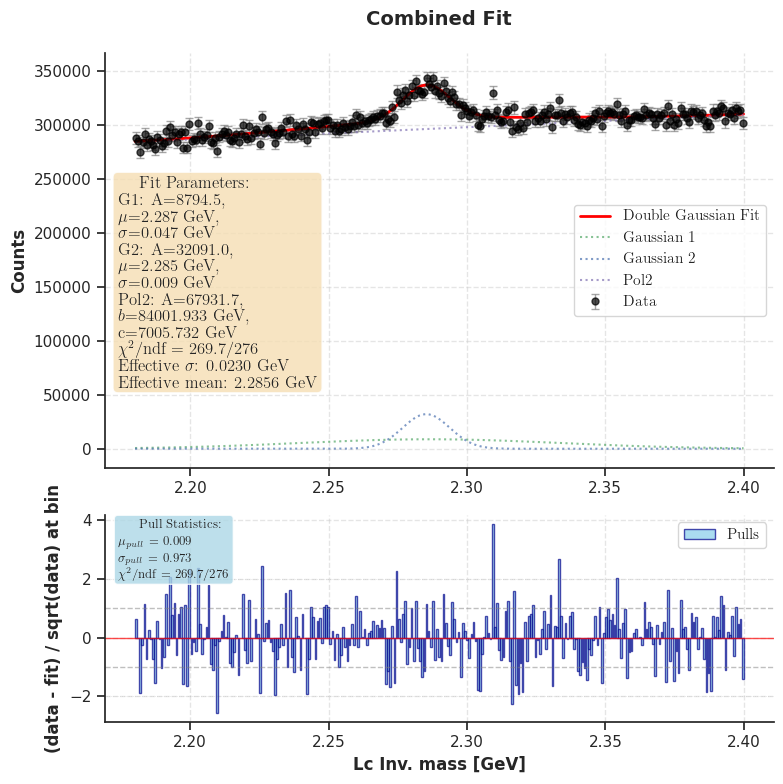

In [6]:
distr_name='total_mass'

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss_and_pol2(
                counts=total_heights,
                errors=total_heights_errors,
                bin_centers=bin_centers,
                bin_edges=bin_edges,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                max_iter=1000,
                scaler=1,
                unit_name='GeV'
            )
        except:
            print(f'Skip method: {method}') 
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss_and_pol2(
    counts=total_heights,
    errors=total_heights_errors,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    title='Combined Fit',
    x_label='Lc Inv. mass [GeV]',
    optimize_method=best_method,
    plot=True,
    max_iter=1000,
    scaler=1,
    unit_name='GeV',
    log_y=False,
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/combined_fit_ML_wide_2gauss_pol2.pdf')

with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/combined_fit_ML_wide_2gauss_pol2.pkl", "wb") as f:
    pickle.dump(result, f)

### S/B Estimates

In [7]:
stat_data = calculate_sb_ratio_2gauss_pol2(
    result[0]['params'],
    bin_edges,
    cov_matrix=result[0]['cov_matrix'],
    mass_interval=CFG.mass_interval
)

stat_data

{'signal': np.float64(1294.7204444282436),
 'background': np.float64(22939.738995322143),
 'S_B_ratio': np.float64(0.056440068681350826),
 'integration_range': (2.24763, 2.32497),
 'S_B_uncertainty': np.float64(0.0018998480615516281)}

### Double Gauss + Pol2 + Exp

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 15
Final objective value: 282.084841
Chi-squared: 282.08
Reduced chi-squared: 1.030
-------------------------------------------

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:2113: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(


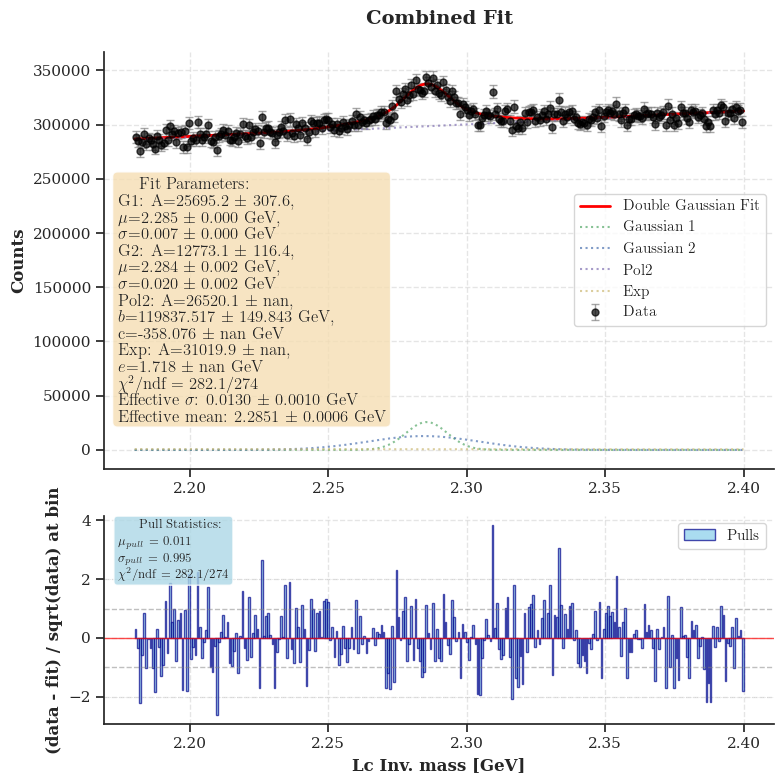

In [9]:
distr_name='total_mass'

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss_and_pol2_end_exp(
                counts=total_heights,
                errors=total_heights_errors,
                bin_centers=bin_centers,
                bin_edges=bin_edges,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                max_iter=1000,
                scaler=1,
                unit_name='GeV'
            )
        except:
            print(f'Skip method: {method}') 
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss_and_pol2_end_exp(
    counts=total_heights,
    errors=total_heights_errors,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    title='Combined Fit',
    x_label='Lc Inv. mass [GeV]',
    optimize_method=best_method,
    plot=True,
    max_iter=1000,
    scaler=1,
    unit_name='GeV',
    log_y=False,
)

# plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/combined_fit_ML.pdf')